In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
DATA_PATH = os.path.join('..', 'data', 'processed', 'ncr_properties_cleaned.parquet')

# Load the Parquet file
df = pd.read_parquet(DATA_PATH)

print(f"Loaded {len(df)} rows from Parquet.")
df.sample()

✅ Loaded 12324 rows from Parquet.


,title,url,city,location,price,price_raw,area,area_raw,bedrooms,bathrooms,...,gym,lift,parking,vastu_compliant,property_hash,scraped_at,society_name,sector,locality,price_per_sqft
5041,"3 BHK Flat for Sale in M3M Marina, Sector 68...",https://www.magicbricks.com/propertyDetails/3-...,Gurugram,Unknown,23500000,₹2.35 Cr₹13889 per sqft,1692.0,,3,0,...,0,0,0,0,3c339a895b46d2fd6bb31e4889d10be6,2026-02-02 15:36:40.664442,M3M Marina,Sector 68,Gurgaon,13889.0


In [27]:
df = df.copy()

df["price_psf"] = df["price"] / df["area"]
df["log_psf"] = np.log1p(df["price_psf"])

df[["price", "area", "price_psf", "log_psf"]].describe()



,price,area,price_psf,log_psf
count,1.232400e+04,12324.000000,12324.000000,12324.000000
mean,1.944142e+07,1535.567267,11123.781164,9.151761
std,2.164290e+07,938.600889,6784.642091,0.578219
min,6.800000e+05,100.000000,1513.944223,7.323134
25%,6.200000e+06,945.000000,6263.890717,8.742716
50%,1.250000e+07,1350.000000,9615.384615,9.171224
75%,2.500000e+07,1875.500000,14092.985996,9.553503
max,2.000000e+08,10000.000000,50000.000000,10.819798


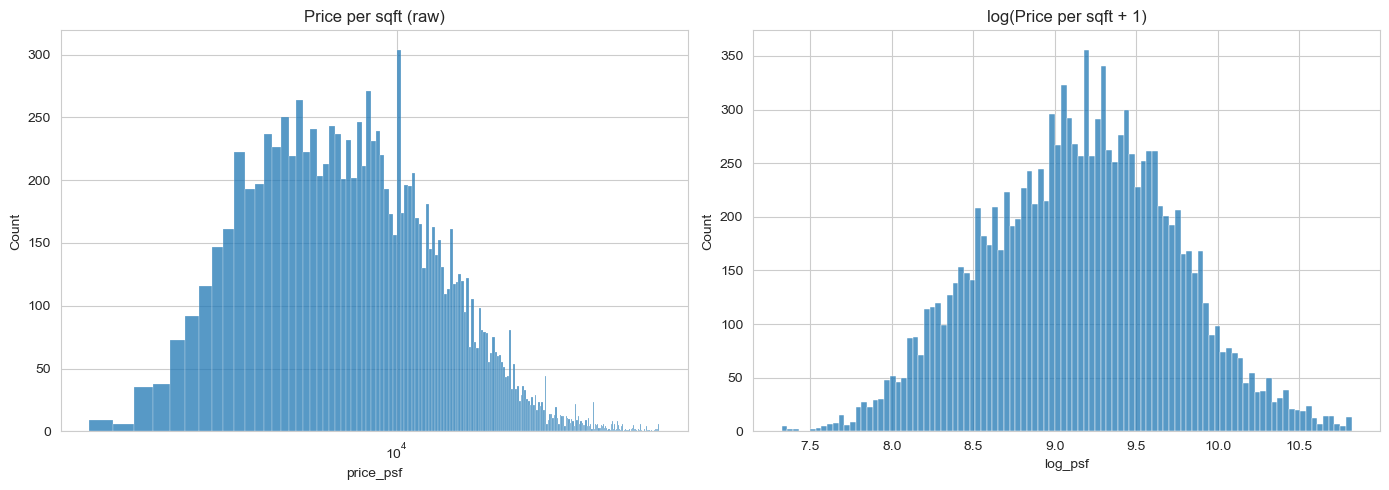

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price_psf"], bins=200, ax=axes[0])
axes[0].set_title("Price per sqft (raw)")
axes[0].set_xscale("log")

sns.histplot(df["log_psf"], bins=100, ax=axes[1])
axes[1].set_title("log(Price per sqft + 1)")

plt.tight_layout()
plt.show()


In [29]:
city_stats = (
    df.groupby("city")["price_psf"]
    .agg(["median", "mean", "std", "count"])
    .sort_values("median", ascending=False)
)

city_stats


,median,mean,std,count
city,,,,
Gurugram,13388.429752,14390.725677,6299.481241,2463
New Delhi,10203.703704,12788.112499,8700.997036,2506
Noida,10169.871211,11370.933823,6291.469807,3320
Greater Noida,8157.319738,8581.482553,4088.159799,1559
Ghaziabad,6666.666667,7472.980993,4296.423465,1926
Faridabad,6509.457018,7409.306928,4306.627975,550


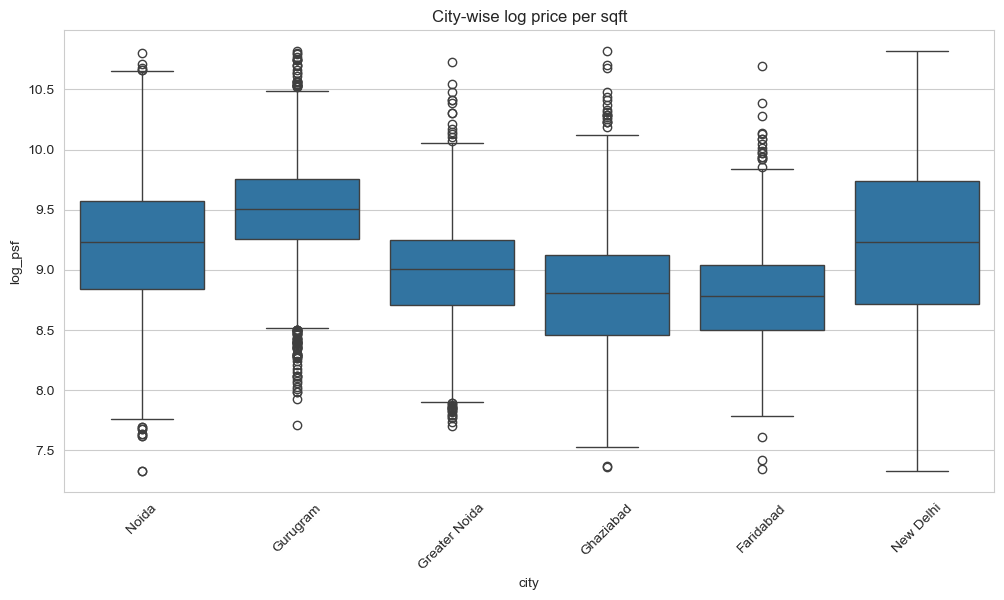

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="city",
    y="log_psf"
)
plt.xticks(rotation=45)
plt.title("City-wise log price per sqft")
plt.show()


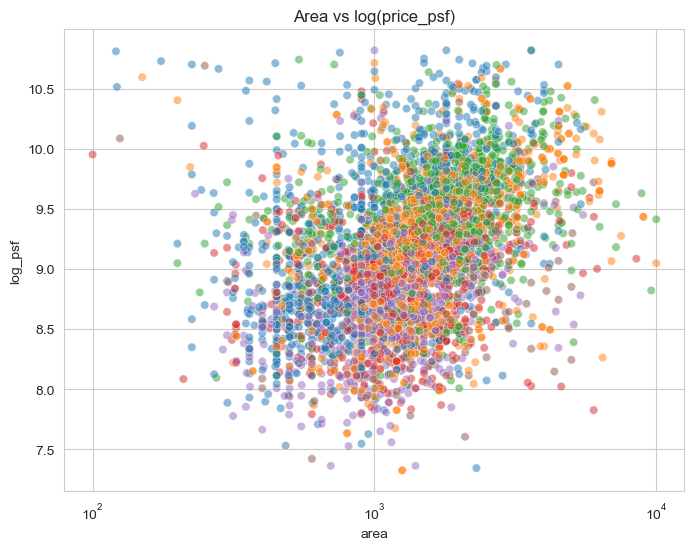

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="area",
    y="log_psf",
    hue="city",
    alpha=0.5,
    legend=False
)
plt.xscale("log")
plt.title("Area vs log(price_psf)")
plt.show()


In [32]:
df["area_bucket"] = pd.qcut(
    df["area"],
    q=10,
    duplicates="drop"
)

(
    df.groupby("area_bucket")["price_psf"]
    .median()
    .reset_index()
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2860\3264063518.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("area_bucket")["price_psf"]


,area_bucket,price_psf
0,"(99.999, 586.3]",6591.928251
1,"(586.3, 855.0]",6710.967856
2,"(855.0, 1000.0]",7301.587302
3,"(1000.0, 1175.0]",8149.903458
4,"(1175.0, 1350.0]",8365.019011
5,"(1350.0, 1535.0]",9966.777409
6,"(1535.0, 1760.0]",11364.934323
7,"(1760.0, 2052.8]",12002.042901
8,"(2052.8, 2593.5]",14000.000000
9,"(2593.5, 10000.0]",15555.555556


In [33]:
df["area_per_bedroom"] = df["area"] / df["bedrooms"]

df["area_per_bedroom"].describe(percentiles=[0.01,0.05,0.95,0.99])


d:\ANACONDA py\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    12324.0
mean         inf
std          NaN
min         20.0
1%         157.5
5%         270.0
50%        525.0
95%        984.5
99%          NaN
max          inf
Name: area_per_bedroom, dtype: float64

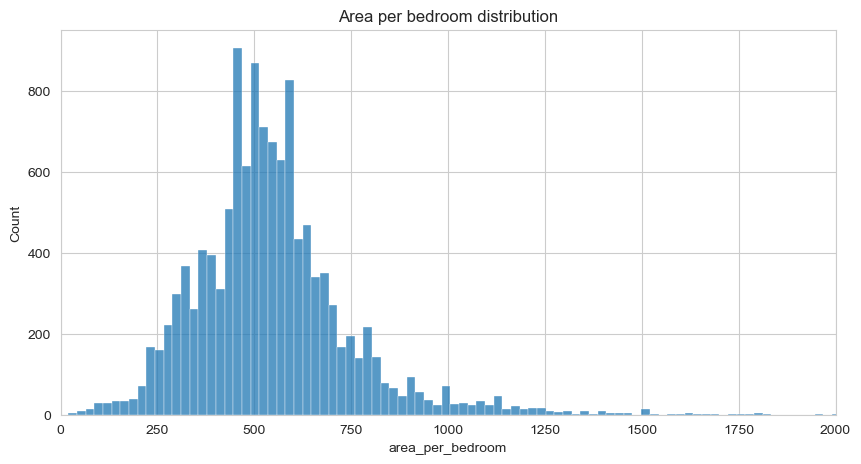

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(df["area_per_bedroom"], bins=200)
plt.xlim(0, 2000)
plt.title("Area per bedroom distribution")
plt.show()


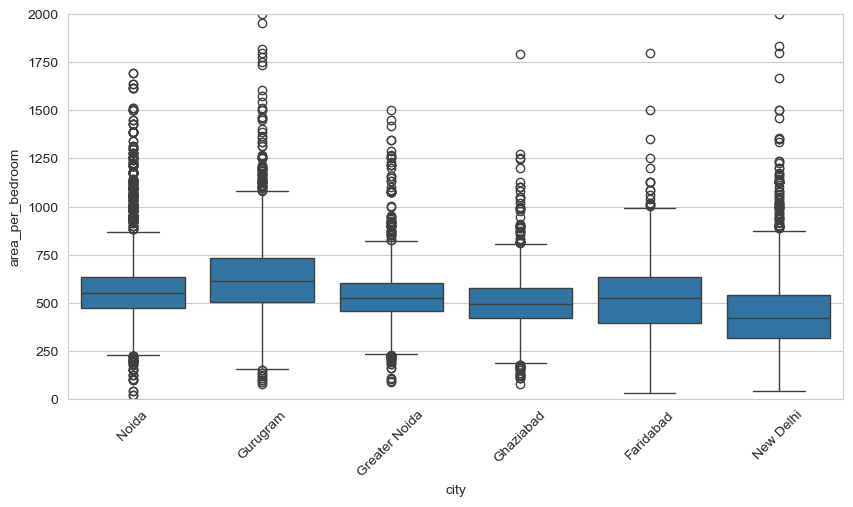

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="city",
    y="area_per_bedroom"
)
plt.ylim(0, 2000)
plt.xticks(rotation=45)
plt.show()


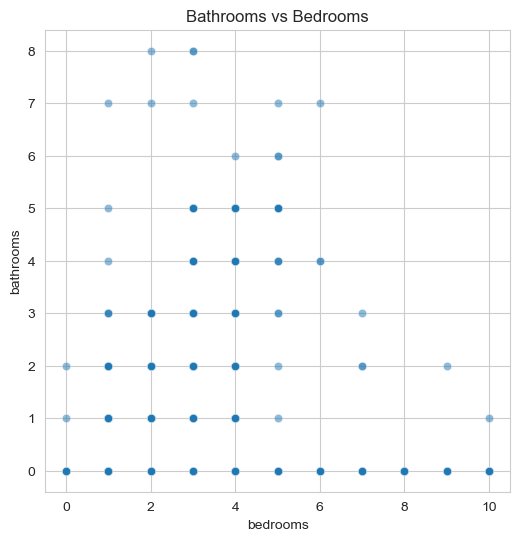

In [36]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=df,
    x="bedrooms",
    y="bathrooms",
    alpha=0.5
)
plt.title("Bathrooms vs Bedrooms")
plt.show()


In [37]:
(df["bathrooms"] - df["bedrooms"]).value_counts().sort_index()


-10      20
-9        7
-8       26
-7       34
-6      113
-5      224
-4     1636
-3     5016
-2     3717
-1     1010
 0      447
 1       52
 2       14
 3        1
 4        2
 5        3
 6        2
Name: count, dtype: int64

In [38]:
locality_stats = (
    df.groupby("locality")["price_psf"]
    .agg(["median", "std", "count"])
    .sort_values("count", ascending=False)
)

locality_stats.head(10)


,median,std,count
locality,,,
Noida,10169.491525,5511.094981,3073
Gurgaon,13265.306122,5574.844680,2297
New Delhi,10000.000000,8183.963677,2173
Ghaziabad,6547.722567,3409.530133,1754
Greater Noida,8193.750000,3483.674491,1372
Faridabad,6333.536338,3291.107616,442
Dadri Road Noida,8364.312268,14765.341274,29
Noida Extension Noida,5151.515152,2820.298617,29
Noida Express Way Noida,9444.444444,9971.039207,29


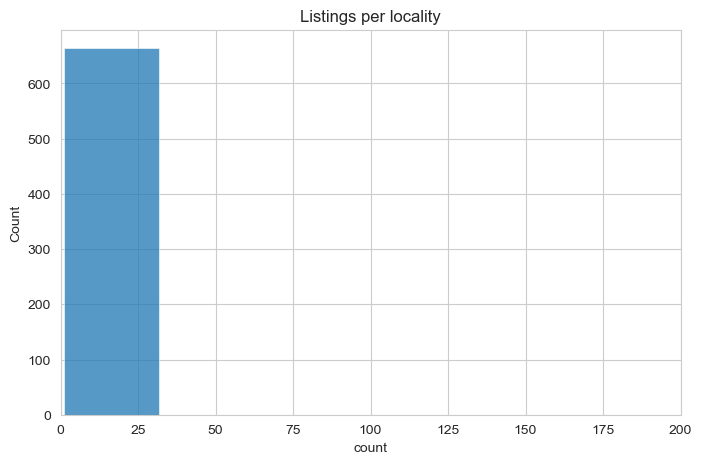

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(locality_stats["count"], bins=100)
plt.xlim(0, 200)
plt.title("Listings per locality")
plt.show()


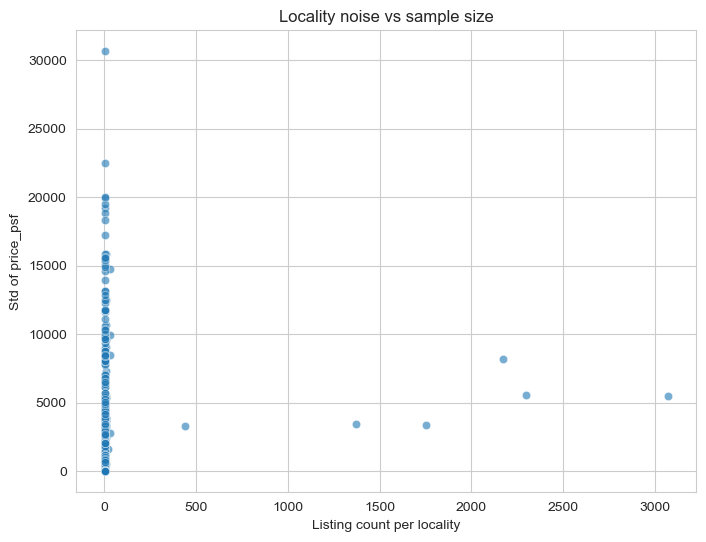

In [40]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=locality_stats["count"],
    y=locality_stats["std"],
    alpha=0.6
)
plt.xlabel("Listing count per locality")
plt.ylabel("Std of price_psf")
plt.title("Locality noise vs sample size")
plt.show()


In [41]:
df["city_psf_99"] = (
    df.groupby("city")["price_psf"]
    .transform(lambda x: x.quantile(0.99))
)

df["psf_city_outlier"] = df["price_psf"] > df["city_psf_99"]

df["psf_city_outlier"].value_counts(normalize=True)


psf_city_outlier
False    0.989938
True     0.010062
Name: proportion, dtype: float64

In [42]:
df.loc[df["psf_city_outlier"], [
    "city", "locality", "area", "price", "price_psf", "bedrooms", "floor"
]].sort_values("price_psf", ascending=False).head(20)


,city,locality,area,price,price_psf,bedrooms,floor
8670,Ghaziabad,Ghaziabad,1000.0,50000000,50000.000000,2,0
12191,New Delhi,Shastri Nagar New Delhi,3000.0,150000000,50000.000000,5,0
9909,New Delhi,New Delhi,3600.0,180000000,50000.000000,4,0
11688,New Delhi,Rajouri Garden New Delhi,1800.0,90000000,50000.000000,9,0
4303,Gurugram,Phase 2 DLF Gurgaon,3600.0,180000000,50000.000000,6,0
10345,New Delhi,New Delhi,2403.0,120000000,49937.578027,4,0
9837,New Delhi,New Delhi,1710.0,85000000,49707.602339,3,26
11316,New Delhi,New Delhi,121.0,6000000,49586.776860,2,2
4823,Gurugram,Golf Course Road Gurgaon,540.0,26500000,49074.074074,5,0
11149,New Delhi,New Delhi,754.0,37000000,49071.618037,2,0


In [43]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct


sector              0.075868
title               0.000000
lift                0.000000
parking             0.000000
vastu_compliant     0.000000
property_hash       0.000000
scraped_at          0.000000
society_name        0.000000
locality            0.000000
pool                0.000000
price_per_sqft      0.000000
price_psf           0.000000
log_psf             0.000000
area_bucket         0.000000
area_per_bedroom    0.000000
city_psf_99         0.000000
gym                 0.000000
store_room          0.000000
url                 0.000000
bedrooms            0.000000
city                0.000000
location            0.000000
price               0.000000
price_raw           0.000000
area                0.000000
area_raw            0.000000
bathrooms           0.000000
servant_room        0.000000
balcony             0.000000
prop_type           0.000000
furnished           0.000000
facing              0.000000
floor               0.000000
pooja_room          0.000000
psf_city_outli

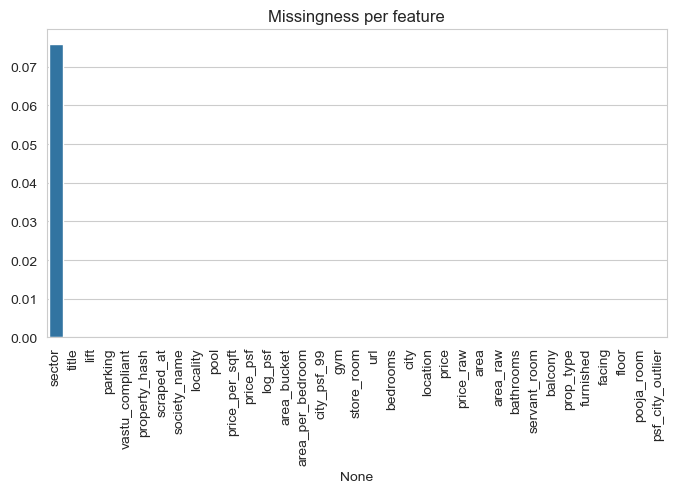

In [44]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing_pct.index,
    y=missing_pct.values
)
plt.xticks(rotation=90)
plt.title("Missingness per feature")
plt.show()


In [45]:
df["floor"].value_counts().head(20)



floor
0     10221
26      287
27      211
2       188
1       179
3       169
28      166
29      111
4       104
30       71
5        53
11       44
14       41
10       39
8        37
12       37
6        36
7        34
9        34
15       34
Name: count, dtype: int64

In [46]:

df.groupby(df["floor"] == 0)["price_psf"].describe()


,count,mean,std,min,25%,50%,75%,max
floor,,,,,,,,
False,2103.0,11921.877270,6846.838633,1543.209877,6713.821922,10551.180577,15523.174645,49707.602339
True,10221.0,10959.570606,6760.433287,1513.944223,6200.000000,9424.083770,13833.992095,50000.000000


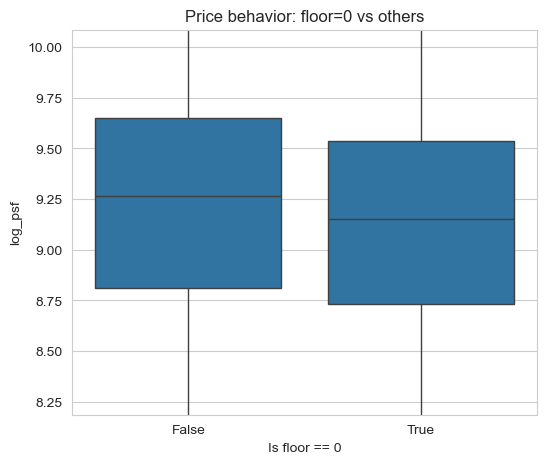

In [47]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df,
    x=(df["floor"] == 0),
    y="log_psf"
)
plt.ylim(
    df["log_psf"].quantile(0.05),
    df["log_psf"].quantile(0.95)
)
plt.xlabel("Is floor == 0")
plt.title("Price behavior: floor=0 vs others")
plt.show()


In [48]:
df["prop_type"].value_counts(dropna=False)



prop_type
Apartment            9283
Independent House    2112
Builder Floor         829
Plot                  100
Name: count, dtype: int64

In [49]:
pd.crosstab(
    df["prop_type"],
    df["floor"],
    normalize="index"
).iloc[:, :6]  # show floors 0–5


floor,0,1,2,3,4,5
prop_type,,,,,,
Apartment,0.845201,0.008833,0.008402,0.010018,0.006033,0.002909
Builder Floor,0.784077,0.056695,0.066345,0.044632,0.020507,0.007238
Independent House,0.780303,0.021307,0.024148,0.017519,0.013731,0.009470
Plot,0.770000,0.050000,0.040000,0.020000,0.020000,0.000000


In [50]:
apt_df = df[df["prop_type"] == "Apartment"]

apt_df["floor"].value_counts(normalize=True).head(10)


floor
0     0.845201
26    0.026285
27    0.018744
28    0.016051
3     0.010018
29    0.009695
1     0.008833
2     0.008402
4     0.006033
30    0.005925
Name: proportion, dtype: float64

In [51]:
apt_df["floor_specified"] = (apt_df["floor"] != 0).astype(int)

apt_df.groupby("floor_specified")["price_psf"].median()


C:\Users\Asus\AppData\Local\Temp\ipykernel_2860\1279114051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apt_df["floor_specified"] = (apt_df["floor"] != 0).astype(int)


floor_specified
0     9259.259259
1    11000.000000
Name: price_psf, dtype: float64

In [52]:
apt_df = df[df["prop_type"] == "Apartment"]

apt_df["floor"].replace(0, np.nan).describe()


count    1437.000000
mean       18.212248
std        10.894987
min         1.000000
25%         6.000000
50%        26.000000
75%        27.000000
max        53.000000
Name: floor, dtype: float64

For apartments (dominant class), floor is sparsely and selectively reported.
floor = 0 represents missing floor information, not a physical ground floor.
Among specified values, floor magnitude shows reporting artifacts and bimodal clustering, making numeric usage unsafe.
Therefore, floor should not be treated as a continuous variable for apartments.
The only reliable apartment-level signal is whether floor information is specified at all.

In [53]:
target = "log_psf"   # NOT raw price


In [54]:
loc_counts = df["locality"].value_counts()

loc_counts.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


count     670.000000
mean       18.394030
std       190.882875
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
90%         3.000000
95%         5.000000
99%        29.000000
max      3073.000000
Name: count, dtype: float64

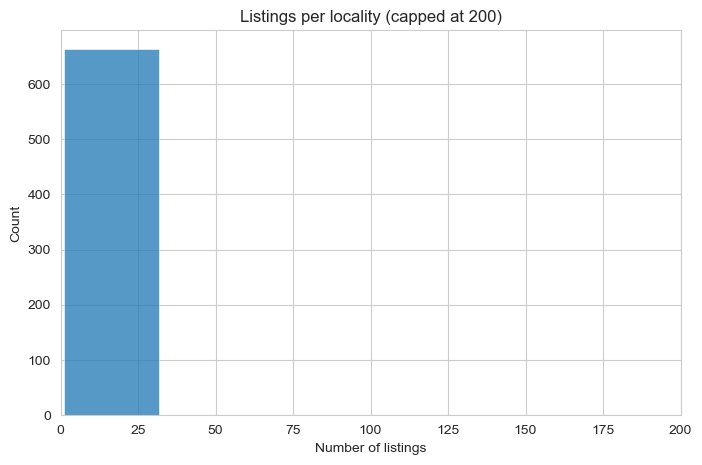

In [55]:
plt.figure(figsize=(8, 5))
sns.histplot(loc_counts, bins=100)
plt.xlim(0, 200)
plt.title("Listings per locality (capped at 200)")
plt.xlabel("Number of listings")
plt.show()


In [56]:
loc_stats = (
    df.groupby("locality")["price_psf"]
    .agg(
        count="count",
        median="median",
        std="std"
    )
    .reset_index()
)


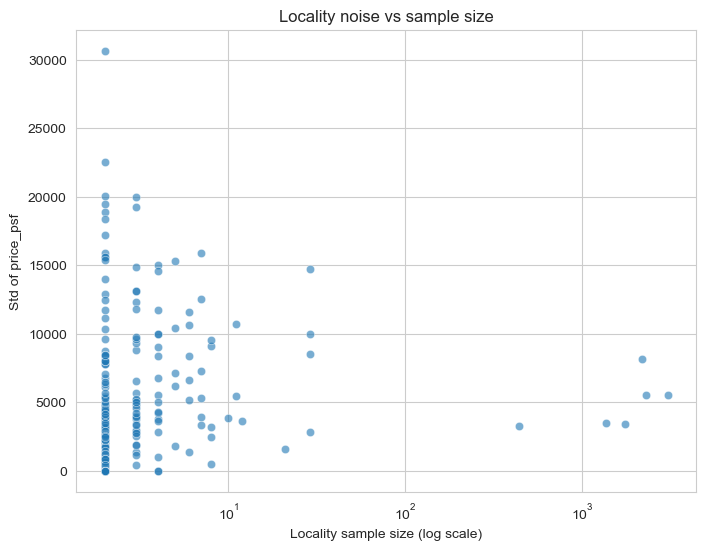

In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=loc_stats,
    x="count",
    y="std",
    alpha=0.6
)
plt.xscale("log")
plt.xlabel("Locality sample size (log scale)")
plt.ylabel("Std of price_psf")
plt.title("Locality noise vs sample size")
plt.show()


In [58]:
loc_stats["count_bucket"] = pd.cut(
    loc_stats["count"],
    bins=[0, 5, 10, 20, 50, 100, 1000],
    labels=["<5", "5-10", "10-20", "20-50", "50-100", "100+"]
)

loc_stats.groupby("count_bucket")["std"].median()


C:\Users\Asus\AppData\Local\Temp\ipykernel_2860\1526932428.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_stats.groupby("count_bucket")["std"].median()


count_bucket
<5        3214.121733
5-10      5977.451601
10-20     5468.455412
20-50     8516.430342
50-100            NaN
100+      3291.107616
Name: std, dtype: float64

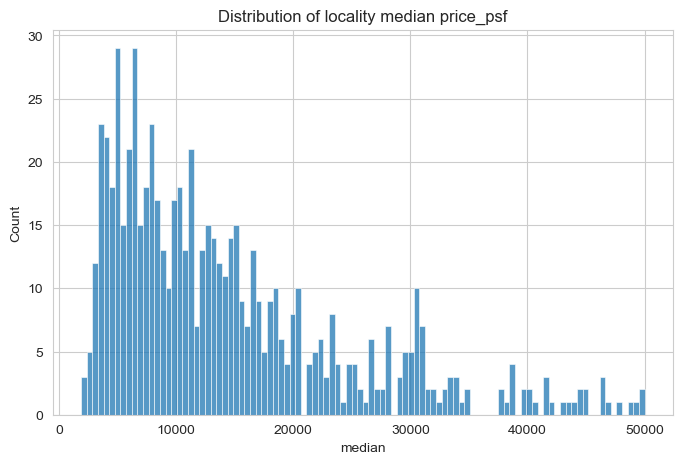

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(loc_stats["median"], bins=100)
plt.title("Distribution of locality median price_psf")
plt.show()


In [60]:
loc_stats = (
    df.groupby("locality")["price_psf"]
    .agg(
        count="count",
        median="median",
        std="std"
    )
    .reset_index()
)


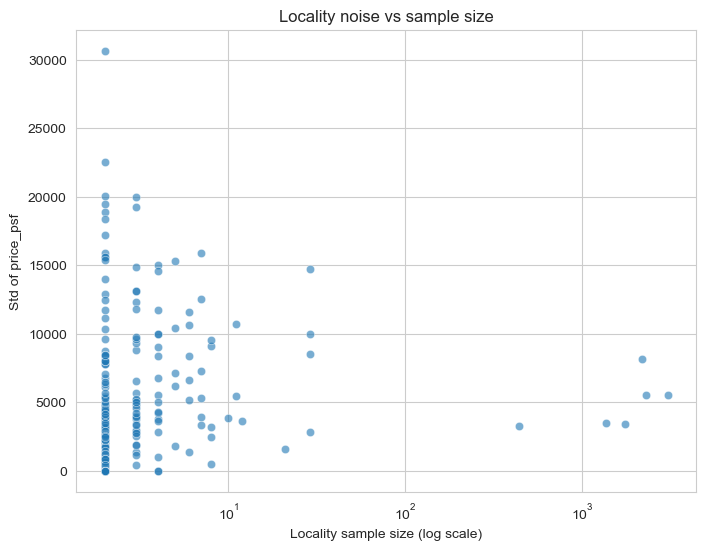

In [61]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=loc_stats,
    x="count",
    y="std",
    alpha=0.6
)
plt.xscale("log")
plt.xlabel("Locality sample size (log scale)")
plt.ylabel("Std of price_psf")
plt.title("Locality noise vs sample size")
plt.show()


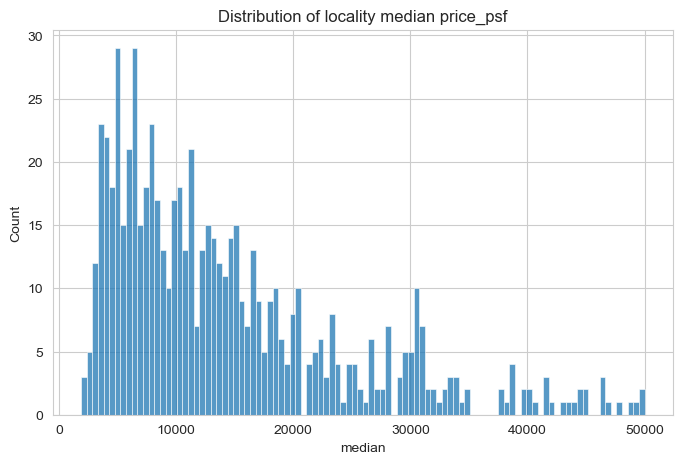

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(loc_stats["median"], bins=100)
plt.title("Distribution of locality median price_psf")
plt.show()


In [63]:
print("Overall std:", df["price_psf"].std())
print("City-level std:",
      df.groupby("city")["price_psf"].median().std())
print("Locality-level std:",
      loc_stats["median"].std())


Overall std: 6784.642091286036
City-level std: 2616.6075239559027
Locality-level std: 10169.406054971945


In [64]:
loc_city_map = (
    df.groupby("locality")["city"]
    .agg(lambda x: x.mode().iloc[0])
)


In [65]:
loc_city_map.head()


locality
2nd Park View Gaur Yamuna city Greater Noida                       Greater Noida
3RK Faridabad                                                          Faridabad
60 yard sunlight colony shiv enclave part 3 basantpur Faridabad        Faridabad
A79 Gf Uttam Nagar New Delhi                                           New Delhi
Abhay Khand 1 Ghaziabad                                                Ghaziabad
Name: city, dtype: object

In [66]:
loc_stats["city"] = loc_stats["locality"].map(loc_city_map)


In [67]:
loc_stats = (
    df.groupby(["locality", "city"])["price_psf"]
    .agg(
        count="count",
        median="median",
        std="std"
    )
    .reset_index()
)


In [68]:
hard_mask = (
    (df["area"] > 200) &
    (df["area"] < 20000) &
    (df["bedrooms"] <= 10) &
    (df["bathrooms"] <= df["bedrooms"] + 3) &
    (df["price_psf"] > 1000) &
    (df["price_psf"] < 200000)
)

df["hard_outlier"] = ~hard_mask
df["hard_outlier"].mean()


0.0029211295034079843

In [70]:
df[df["bathrooms"] > df["bedrooms"] + 3][
    ["prop_type","bedrooms","bathrooms","area","price_psf"]
].head(10)


,prop_type,bedrooms,bathrooms,area,price_psf
5654,Apartment,2,8,1300.0,7307.692308
7362,Apartment,3,7,1730.0,6069.364162
8229,Apartment,2,7,1270.0,5905.511811
9012,Apartment,1,7,377.0,6631.299735
10025,Apartment,3,8,1156.0,17301.038062
10822,Apartment,3,8,3200.0,18750.000000
11908,Apartment,1,5,400.0,4500.000000


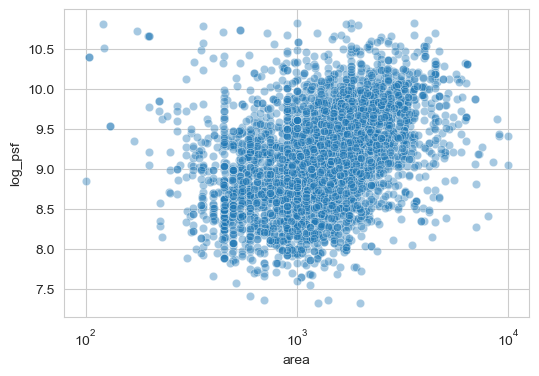

In [71]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df.sample(min(5000,len(df))),
    x="area",
    y="log_psf",
    alpha=0.4
)
plt.xscale("log")
plt.show()


In [72]:
df.groupby("prop_type")["price_psf"].median()


prop_type
Apartment             9500.000000
Builder Floor         8888.888889
Independent House    10344.827586
Plot                 11527.519345
Name: price_psf, dtype: float64

In [73]:
for col in ["lift","parking","gym","pool"]:
    print(col)
    print(df.groupby(col)["price_psf"].median())


lift
lift
0     9504.273504
1    10989.010989
Name: price_psf, dtype: float64
parking
parking
0     9259.259259
1    10344.827586
Name: price_psf, dtype: float64
gym
gym
0     9565.217391
1    10862.619808
Name: price_psf, dtype: float64
pool
pool
0     9278.350515
1    11003.717472
Name: price_psf, dtype: float64


In [74]:
df[["area","bedrooms","bathrooms"]].corr()


,area,bedrooms,bathrooms
area,1.000000,0.661606,0.056644
bedrooms,0.661606,1.000000,0.054643
bathrooms,0.056644,0.054643,1.000000


In [75]:
df[["bedrooms","bathrooms"]].value_counts().head(10)


bedrooms  bathrooms
3         0            5007
2         0            3677
4         0            1634
1         0             867
5         0             222
0         0             178
2         2             120
6         0             113
3         3             104
          2             100
Name: count, dtype: int64

In [76]:
(df["bedrooms"] == 0).mean()


0.014605647517039922

In [69]:
df.columns.unique()

Index(['title', 'url', 'city', 'location', 'price', 'price_raw', 'area',
       'area_raw', 'bedrooms', 'bathrooms', 'balcony', 'prop_type',
       'furnished', 'facing', 'floor', 'pooja_room', 'servant_room',
       'store_room', 'pool', 'gym', 'lift', 'parking', 'vastu_compliant',
       'property_hash', 'scraped_at', 'society_name', 'sector', 'locality',
       'price_per_sqft', 'price_psf', 'log_psf', 'area_bucket',
       'area_per_bedroom', 'city_psf_99', 'psf_city_outlier', 'hard_outlier'],
      dtype='object')